In [1]:
import sys
from datetime import datetime, timedelta

import xarray as xr
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib
import matplotlib.ticker as ticker
from scipy import stats
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import matplotlib.ticker as mticker
from matplotlib.legend_handler import HandlerTuple
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import dask
#import rasterio
import os 
os.listdir("/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/GRq/spin2/work")

import matplotlib.colors as mcolors # Import les palettes de couleurs
import cartopy.crs as ccrs # Permet d'utiliser des projections de cartes
import cartopy.feature as cfeature # Permet d'ajouter d'autres éléments à la carte
import matplotlib.patches as patches # Permet de tracer des rectangles dans mon cas

In [2]:
k = 15

iyear=1960
fyear=2025

ice_level = 30 # Seuil à partir duquel on considère qu'on observe de la glace

In [3]:
GridPath='/home/amoryc/'
Domain_grM='NST.2000.01.01.00.GRq.nc'

ds_grM= xr.open_dataset(GridPath+Domain_grM)

ds_lon = ds_grM.LON[k:-k, k:-k] # Longitude
ds_lat = ds_grM.LAT[k:-k, k:-k] # Latitude
ds_SH  = ds_grM.SH[k:-k, k:-k] # Topographie en m
ds_ICE = ds_grM.ICE[k:-k, k:-k] # Pourcentage de glace par maille

# Coordonnées exactes du Peak Mera
merap_lat = 27.70984
merap_lon = 86.868662

# Coordonnées Everest
everest_lat = 27.9879017
everest_lon = 86.9253141

# Loading MAR data

In [4]:
####### Data loading ######

variable1 = 'RF' # Rain Fall
DataPath1 = '/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/GRq/spin2/work/monthly/' # On regarde les données monthly car même chose que daily en moins long
RF = xr.open_mfdataset(DataPath1+variable1+f'_monsum_MARv3.14_ER5_spin2_GRq_*.nc',combine="by_coords")['RF'] 

variable2 = 'SF' # Snow Fall
DataPath2 = '/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/GRq/spin2/work/monthly/' # On regarde les données monthly car même chose que daily en moins long
SF = xr.open_mfdataset(DataPath2+variable2+f'_monsum_MARv3.14_ER5_spin2_GRq_*.nc',combine="by_coords")['SF'] 

TF = RF + SF # Total fall 

#TF = TF.isel(SECTOR=0)
TF = TF.rename({'TIME': 'time'})
TF = TF[:,k:-k,k:-k].sel(time=slice(str(iyear),str(fyear))) # restreint au bord le domaine et sélectionne les années voulues

In [5]:
########## Traitement de la variable TF #########
ds = TF.sel(time=slice(f"{iyear-1}-12", f"{fyear}-12"))

annual_values = ds.groupby("time.year").sum(dim="time", skipna=True)

annual_mean = annual_values.mean(dim="year", skipna=True)

annual_mean_masked = annual_mean.where(annual_mean != 0)

# Mean Precipitation over Khumbu and Nepal

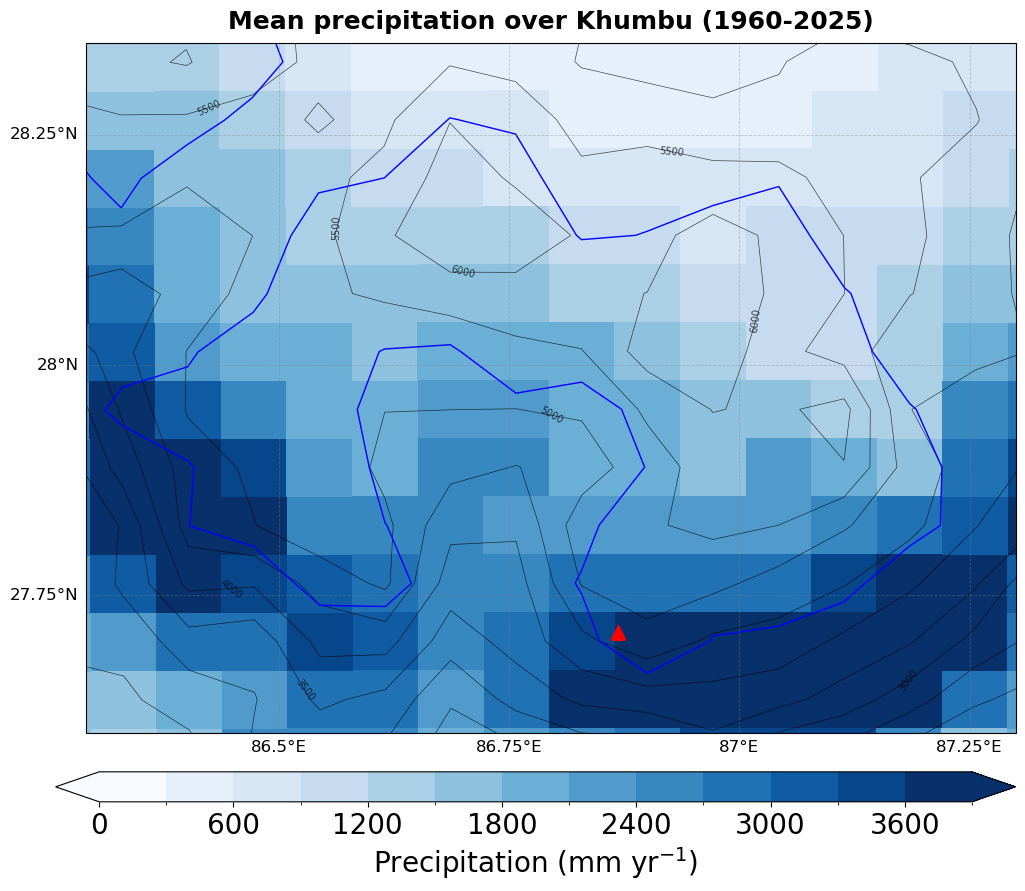

In [6]:
############### Mean precip Map over Khumbu (1960-2025) #######################

fig, ax = plt.subplots(figsize=(12,12),subplot_kw={'projection': ccrs.PlateCarree()}) # Utilisation de la projection plate carré


############# Color map ###############
vmax = 3900
step = 300
levels = np.arange(0, vmax + step, step)
base_cmap = plt.get_cmap("Blues", len(levels)-1)
colors = base_cmap(np.arange(base_cmap.N))

cmap = mcolors.ListedColormap(colors)
#cmap.set_bad(color="white")
norm = mcolors.BoundaryNorm(levels, ncolors=len(colors))


########################################
############### Plot ###################

########### Topography lines #############
SH = ax.contour(ds_lon, ds_lat, ds_SH, levels=np.arange(500, 7001, 500), colors="k", linewidths=0.5, alpha=0.7, transform=ccrs.PlateCarree())

########### Topography lines values #############
manual_locations = [(86.55, 27.65),(86.4,28.3),(86.45, 27.75),(86.80, 27.95),(87.00, 28.05),(86.55, 28.15),(86.90, 28.20),(87.2,27.65),(86.7,28.1)]
ax.clabel(SH, inline=False, fontsize=7, fmt='%d', manual=manual_locations)

######## Countour glaciers #########
ax.contour(ds_lon, ds_lat, ds_ICE, levels=[ice_level], colors="b", linewidths=1, transform=ccrs.PlateCarree()) # Défini les lignes de contour des glaciers (bleu) où la grille dépasse la valeur de ice_level

######## Mera Peak coord #########
ax.plot(merap_lon, merap_lat, marker='^', markersize=10, markerfacecolor='red', markeredgecolor='red', transform=ccrs.PlateCarree()) # Coord exact du Mera Peak


############# TF moyen par point de grille ##############
im = ax.pcolormesh(ds_lon, ds_lat, annual_mean_masked, cmap=cmap, norm=norm, transform=ccrs.PlateCarree(),shading="auto") 


########### Graphic features ############
gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.6,color="gray",alpha=0.4,linestyle="--")
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 12}
gl.ylabel_style = {"size": 12}
gl.xlocator = mticker.MaxNLocator(5)  # max 5 ticks
gl.ylocator = mticker.MaxNLocator(3)

ax.set_extent([86.29, 87.3, 27.6, 28.35], crs=ccrs.PlateCarree()) # Défini les limites (lon, lat) du domaine observable 

ax.set_title(f"Mean precipitation over Khumbu ({iyear}-{fyear})",fontsize=18,weight="bold", pad=10)

######################################
######################################


############## Color bar ##################
cbar_ax = fig.add_axes([0.1, 0.15, 0.8, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='both')
cbar.set_label("Precipitation (mm yr$^{-1}$)", fontsize=20)
cbar.ax.tick_params(labelsize=20)

plt.savefig("Mean_TF_Khumbu.png")

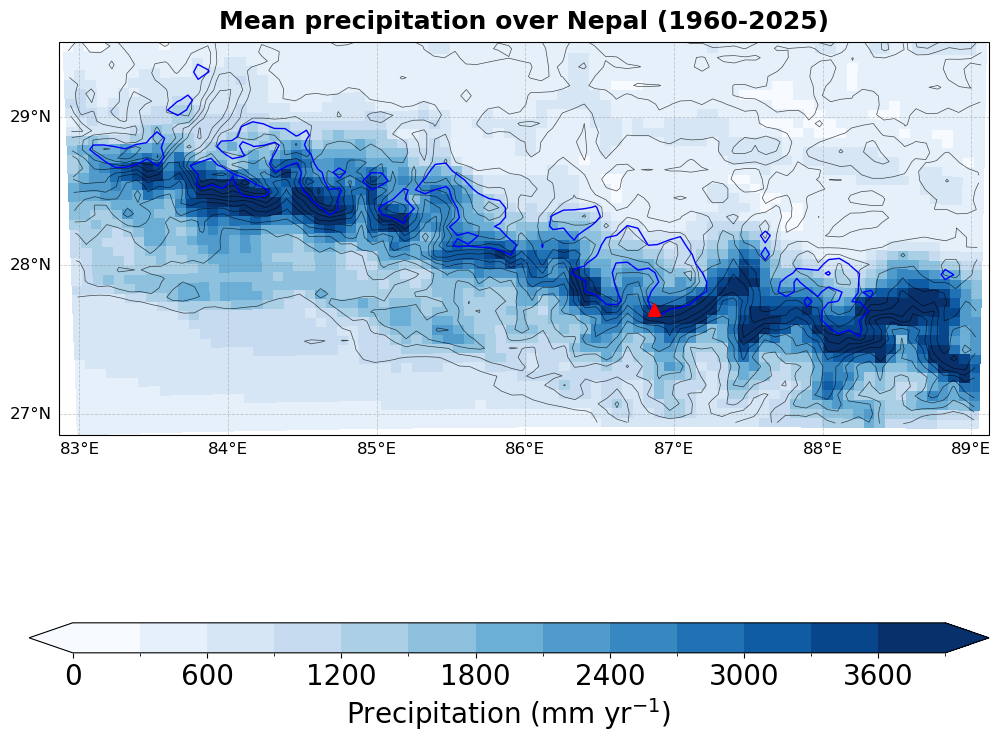

In [7]:
############### Mean precip Map over Nepal (1960-2025) #######################

fig, ax = plt.subplots(figsize=(12,12),subplot_kw={'projection': ccrs.PlateCarree()}) # Utilisation de la projection plate carré


############# Color map ###############
vmax = 3900
step = 300
levels = np.arange(0, vmax + step, step)
base_cmap = plt.get_cmap("Blues", len(levels)-1)
colors = base_cmap(np.arange(base_cmap.N))

cmap = mcolors.ListedColormap(colors)
#cmap.set_bad(color="white")
norm = mcolors.BoundaryNorm(levels, ncolors=len(colors))


########################################
############### Plot ###################

########### Topography lines #############
SH = ax.contour(ds_lon, ds_lat, ds_SH, levels=np.arange(500, 7001, 500), colors="k", linewidths=0.5, alpha=0.7, transform=ccrs.PlateCarree())

######## Countour glaciers #########
ax.contour(ds_lon, ds_lat, ds_ICE, levels=[ice_level], colors="b", linewidths=1, transform=ccrs.PlateCarree()) # Défini les lignes de contour des glaciers (bleu) où la grille dépasse la valeur de ice_level

######## Mera Peak coord #########
ax.plot(merap_lon, merap_lat, marker='^', markersize=8, markerfacecolor='red', markeredgecolor='red',transform=ccrs.PlateCarree()) # Coord exact du Mera Peak


############# TF moyen par point de grille ##############
im = ax.pcolormesh(ds_lon, ds_lat, annual_mean_masked, cmap=cmap, norm=norm, transform=ccrs.PlateCarree(),shading="auto") 


########### Graphic features ############
gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.6,color="gray",alpha=0.4,linestyle="--")
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 12}
gl.ylabel_style = {"size": 12}
gl.xlocator = mticker.MaxNLocator(7)  # max 7 ticks
gl.ylocator = mticker.MaxNLocator(3)

lon_min, lon_max, lat_min, lat_max = ax.get_extent(ccrs.PlateCarree())
ax.set_extent([lon_min, lon_max, lat_min, 29.5],crs=ccrs.PlateCarree())

ax.set_title(f"Mean precipitation over Nepal ({iyear}-{fyear})",fontsize=18,weight="bold", pad=10)

######################################
######################################


############## Color bar ##################
cbar_ax = fig.add_axes([0.1, 0.15, 0.8, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='both')
cbar.set_label("Precipitation (mm yr$^{-1}$)", fontsize=20)
cbar.ax.tick_params(labelsize=20)

plt.savefig("Mean_TF_Nepal.png")

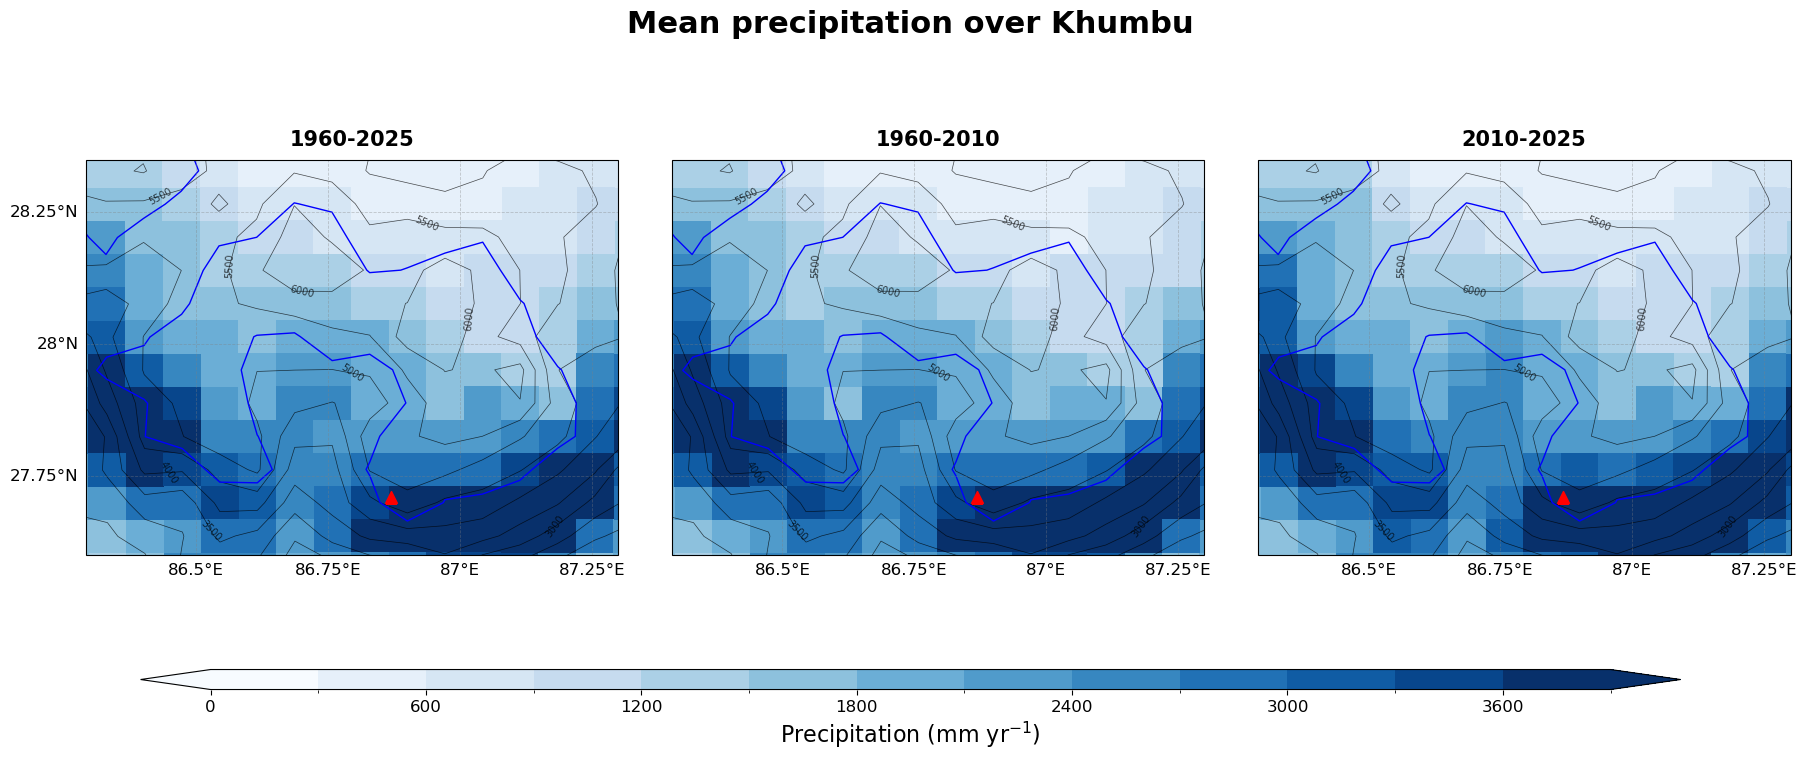

In [8]:
############### Subplot Mean TF Map khumbu #######################

fig, axes = plt.subplots(1, 3, figsize=(22, 8), subplot_kw={'projection': ccrs.PlateCarree()})

########## Périodes étudiées ##########
periods = [(1960, 2025), (1960, 2010), (2010, 2025)]

########## Color map ###############
vmax = 3900
step = 300
levels = np.arange(0, vmax + step, step)
base_cmap = plt.get_cmap("Blues", len(levels)-1)
colors = base_cmap(np.arange(base_cmap.N))

cmap = mcolors.ListedColormap(colors)
#cmap.set_bad(color="white")
norm = mcolors.BoundaryNorm(levels, ncolors=len(colors))


#############################################################
############### Boucles pour les périodes ###################
for ax, (start, end) in zip(axes, periods):

    ds = TF.sel(time=slice(f"{start}-01", f"{end}-12")) # Selection de période

    annual_values = ds.groupby("time.year").sum(dim="time", skipna=True)
    annual_mean = annual_values.mean(dim="year", skipna=True)

    annual_mean_masked = annual_mean.where(annual_mean != 0)
    
    ############### Plot ###############
    ########### Topography lines #############
    SH = ax.contour(ds_lon, ds_lat, ds_SH, levels=np.arange(500, 7001, 500), colors="k", linewidths=0.5, alpha=0.7, transform=ccrs.PlateCarree())

    ########### Topography lines values #############
    manual_locations = [(86.55, 27.65),(86.4,28.3),(86.45, 27.75),(86.80, 27.95),(87.00, 28.05),(86.55, 28.15),(86.90, 28.20),(87.2,27.65),(86.7,28.1)]
    ax.clabel(SH, inline=False, fontsize=7, fmt='%d', manual=manual_locations)

    ######## Countour glaciers #########
    ax.contour(ds_lon, ds_lat, ds_ICE, levels=[ice_level], colors="b", linewidths=1, transform=ccrs.PlateCarree()) # Défini les lignes de contour des glaciers (bleu) où la grille dépasse la valeur de ice_level

    ######## Mera Peak coord #########
    ax.plot(merap_lon, merap_lat, marker='^', markersize=8, markerfacecolor='red', markeredgecolor='red', transform=ccrs.PlateCarree()) # Coord exact du Mera Peak

    ############# TF moyen par point de grille ##############
    im = ax.pcolormesh(ds_lon, ds_lat, annual_mean_masked, cmap=cmap, norm=norm, transform=ccrs.PlateCarree(),shading="auto") 

    

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.6,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False

    if ax != axes[0]: # labels seulement sur le subplot gauche
        gl.left_labels = False
        
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}
    gl.xlocator = mticker.MaxNLocator(5)  # max 5 ticks
    gl.ylocator = mticker.MaxNLocator(3)
    ax.set_extent([86.29, 87.3, 27.6, 28.35], crs=ccrs.PlateCarree()) # Défini les limites (lon, lat) du domaine observable 
    
    ax.set_title(f"{start}-{end}",fontsize=15,weight="bold", pad=10)

#######################################################################
#######################################################################
    


fig.suptitle("Mean precipitation over Khumbu", fontsize=22, weight="bold", y=0.93) 

cbar_ax = fig.add_axes([0.15, 0.08, 0.7, 0.025])

cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='both')

cbar.set_label("Precipitation (mm yr$^{-1}$)", fontsize=16)

cbar.ax.tick_params(labelsize=12)

plt.subplots_adjust(wspace=0.1) # Espacement subplots

plt.savefig("Mean_TF_Khumbu_subperiod.png")

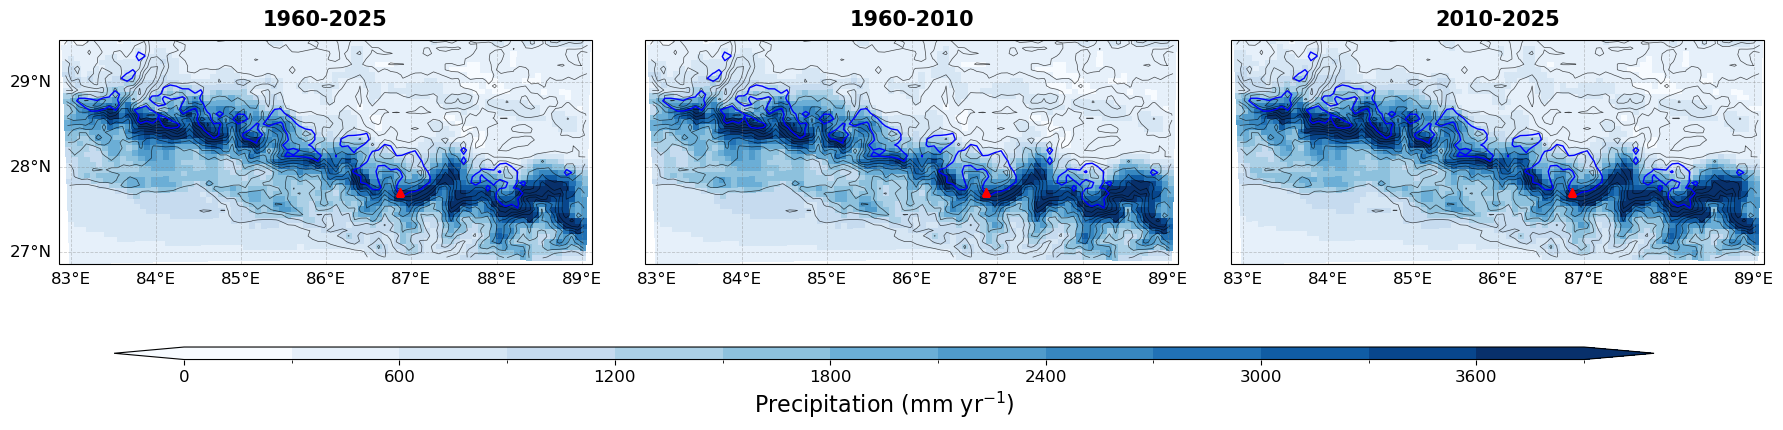

In [9]:
############### Subplot Mean TF Map Nepal #######################

fig, axes = plt.subplots(1, 3, figsize=(22, 5), subplot_kw={'projection': ccrs.PlateCarree()})

########## Périodes étudiées ##########
periods = [(1960, 2025), (1960, 2010), (2010, 2025)]

########## Color map ###############
vmax = 3900
step = 300
levels = np.arange(0, vmax + step, step)
base_cmap = plt.get_cmap("Blues", len(levels)-1)
colors = base_cmap(np.arange(base_cmap.N))

cmap = mcolors.ListedColormap(colors)
#cmap.set_bad(color="white")
norm = mcolors.BoundaryNorm(levels, ncolors=len(colors))


#############################################################
############### Boucles pour les périodes ###################
for ax, (start, end) in zip(axes, periods):

    ds = TF.sel(time=slice(f"{start}-01", f"{end}-12")) # Selection de période

    annual_values = ds.groupby("time.year").sum(dim="time", skipna=True)
    annual_mean = annual_values.mean(dim="year", skipna=True)

    annual_mean_masked = annual_mean.where(annual_mean != 0)
    
    ############### Plot ###############
    ########### Topography lines #############
    SH = ax.contour(ds_lon, ds_lat, ds_SH, levels=np.arange(500, 7001, 500), colors="k", linewidths=0.5, alpha=0.7, transform=ccrs.PlateCarree())
    
    ######## Countour glaciers #########
    ax.contour(ds_lon, ds_lat, ds_ICE, levels=[ice_level], colors="b", linewidths=1, transform=ccrs.PlateCarree()) # Défini les lignes de contour des glaciers (bleu) où la grille dépasse la valeur de ice_level

    ######## Mera Peak coord #########
    ax.plot(merap_lon, merap_lat, marker='^', markersize=6, markerfacecolor='red', markeredgecolor='red', transform=ccrs.PlateCarree()) # Coord exact du Mera Peak

    ############# TF moyen par point de grille ##############
    im = ax.pcolormesh(ds_lon, ds_lat, annual_mean_masked, cmap=cmap, norm=norm, transform=ccrs.PlateCarree(),shading="auto") 

    

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.6,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.xlocator = mticker.MaxNLocator(7)  # max 5 ticks
    gl.ylocator = mticker.MaxNLocator(3)

    lon_min, lon_max, lat_min, lat_max = ax.get_extent(ccrs.PlateCarree())
    ax.set_extent([lon_min, lon_max, lat_min, 29.5],crs=ccrs.PlateCarree())

    if ax != axes[0]: # labels seulement sur le subplot gauche
        gl.left_labels = False
        
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

    
    ax.set_title(f"{start}-{end}",fontsize=15,weight="bold", pad=10)

#######################################################################
#######################################################################
    



cbar_ax = fig.add_axes([0.15, 0.08, 0.7, 0.025])

cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='both')

cbar.set_label("Precipitation (mm yr$^{-1}$)", fontsize=16)

cbar.ax.tick_params(labelsize=12)

plt.subplots_adjust(wspace=0.1) # Espacement subplots



# Difference between two period

In [10]:
########## Périodes étudiées ##########
period1 = (1960, 2010)
period2 = (2010, 2025)

########## Fonction pour calculer la Temperature moyen ##########
def compute_mean_tf(start, end):

    ds = TF.sel(time=slice(f"{start}-01", f"{end}-12"))

    annual_values = ds.groupby("time.year").sum(dim="time", skipna=True)

    annual_mean = annual_values.mean(dim="year")

    return annual_mean

tf_1 = compute_mean_tf(*period1)
tf_2 = compute_mean_tf(*period2)
tf_diff = tf_2 - tf_1

maps = [(tf_1, f"{period1[0]}-{period1[1]}"), (tf_2, f"{period2[0]}-{period2[1]}"), (tf_diff, "Difference")]


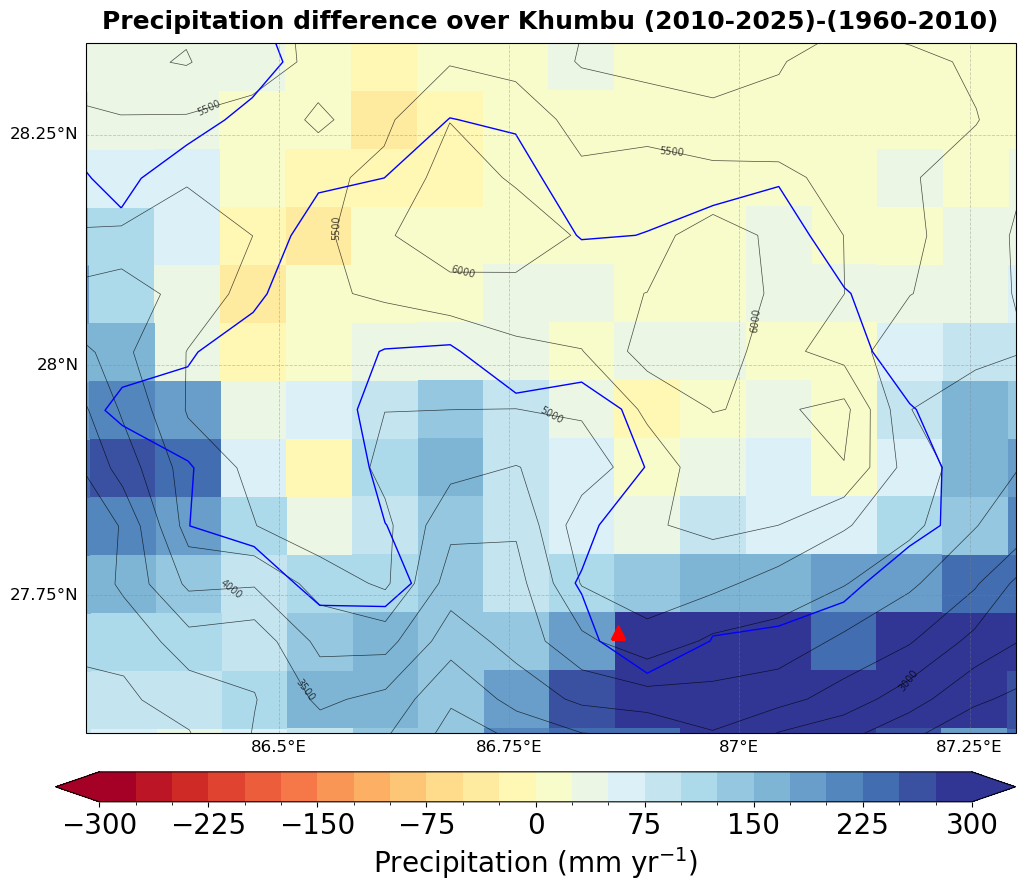

In [11]:
############### TF diff MAP of Khumbu (2010-2025)-(1960-2010) #######################

fig, ax = plt.subplots(figsize=(12,12),subplot_kw={'projection': ccrs.PlateCarree()}) # Utilisation de la projection plate carré

data_masked = tf_diff.where(tf_diff != 0) # Permet de mettre en blanc les valeurs strictement égales à 0

############# Color map ###############
vmax = 300
step = 25
levels = np.arange(-vmax, vmax + step, step)
base_cmap = plt.get_cmap("RdYlBu", len(levels)-1)
colors = base_cmap(np.arange(base_cmap.N))

cmap = mcolors.ListedColormap(colors)
#cmap.set_bad(color="white")
norm = mcolors.BoundaryNorm(levels, ncolors=len(colors))


########################################
############### Plot ###################

########### Topography lines #############
SH = ax.contour(ds_lon, ds_lat, ds_SH, levels=np.arange(500, 7001, 500), colors="k", linewidths=0.5, alpha=0.7, transform=ccrs.PlateCarree())

########### Topography lines values #############
manual_locations = [(86.55, 27.65),(86.4,28.3),(86.45, 27.75),(86.80, 27.95),(87.00, 28.05),(86.55, 28.15),(86.90, 28.20),(87.2,27.65),(86.7,28.1)]
ax.clabel(SH, inline=False, fontsize=7, fmt='%d', manual=manual_locations)

######## Countour glaciers #########
ax.contour(ds_lon, ds_lat, ds_ICE, levels=[ice_level], colors="b", linewidths=1, transform=ccrs.PlateCarree()) # Défini les lignes de contour des glaciers (bleu) où la grille dépasse la valeur de ice_level

######## Mera Peak coord #########
ax.plot(merap_lon, merap_lat, marker='^', markersize=10, markerfacecolor='red', markeredgecolor='red', transform=ccrs.PlateCarree()) # Coord exact du Mera Peak


############# TF moyen par point de grille ##############
im = ax.pcolormesh(ds_lon, ds_lat, data_masked, cmap=cmap, norm=norm, transform=ccrs.PlateCarree(),shading="auto") 


########### Graphic features ############
gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.6,color="gray",alpha=0.4,linestyle="--")
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 12}
gl.ylabel_style = {"size": 12}
gl.xlocator = mticker.MaxNLocator(5)  # max 5 ticks
gl.ylocator = mticker.MaxNLocator(3)

ax.set_extent([86.29, 87.3, 27.6, 28.35], crs=ccrs.PlateCarree()) # Défini les limites (lon, lat) du domaine observable 

ax.set_title(f"Precipitation difference over Khumbu ({2010}-{fyear})-({iyear}-{2010})",fontsize=18,weight="bold", pad=10)

######################################
######################################


############## Color bar ##################
cbar_ax = fig.add_axes([0.1, 0.15, 0.8, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='both')
cbar.set_label("Precipitation (mm yr$^{-1}$)", fontsize=20)
cbar.ax.tick_params(labelsize=20)

#plt.savefig("Mean_TF_diff_Khumbu.png")

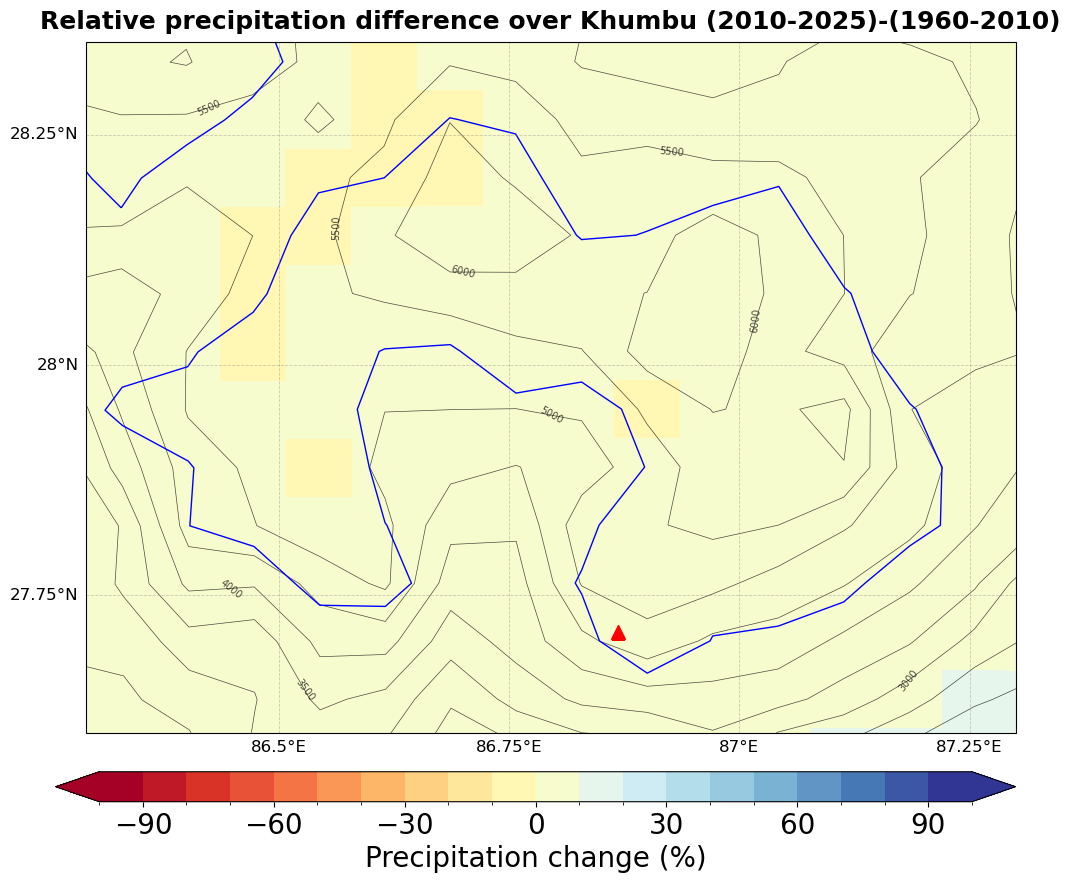

In [12]:
############### Relative TF diff MAP of Khumbu (2010-2025)-(1960-2010) #######################

fig, ax = plt.subplots(figsize=(12,12),subplot_kw={'projection': ccrs.PlateCarree()}) # Utilisation de la projection plate carré

############# Différence relative (%) ##############

# On veut exprimer la différence en %, pour regarder changement relatif entre 2 périodes. On a donc t_diff qui est tf_2 - tf_1 (moyenne de période 2, moins la 1)
# Divisé par la période 1
tf_diff_percent = (tf_diff/tf_1)*100

tf_diff_percent = tf_diff_percent.where(annual_mean > 0) # Évite les divisions par zéro

data_masked = tf_diff_percent.where(np.isfinite(tf_diff_percent))

############# Color map ###############
vmax = 100
step = 10
levels = np.arange(-vmax, vmax + step, step)
base_cmap = plt.get_cmap("RdYlBu", len(levels)-1)
colors = base_cmap(np.arange(base_cmap.N))

cmap = mcolors.ListedColormap(colors)
#cmap.set_bad(color="white")
norm = mcolors.BoundaryNorm(levels, ncolors=len(colors))


########################################
############### Plot ###################

########### Topography lines #############
SH = ax.contour(ds_lon, ds_lat, ds_SH, levels=np.arange(500, 7001, 500), colors="k", linewidths=0.5, alpha=0.7, transform=ccrs.PlateCarree())

########### Topography lines values #############
manual_locations = [(86.55, 27.65),(86.4,28.3),(86.45, 27.75),(86.80, 27.95),(87.00, 28.05),(86.55, 28.15),(86.90, 28.20),(87.2,27.65),(86.7,28.1)]
ax.clabel(SH, inline=False, fontsize=7, fmt='%d', manual=manual_locations)

######## Countour glaciers #########
ax.contour(ds_lon, ds_lat, ds_ICE, levels=[ice_level], colors="b", linewidths=1, transform=ccrs.PlateCarree()) # Défini les lignes de contour des glaciers (bleu) où la grille dépasse la valeur de ice_level

######## Mera Peak coord #########
ax.plot(merap_lon, merap_lat, marker='^', markersize=10, markerfacecolor='red', markeredgecolor='red', transform=ccrs.PlateCarree()) # Coord exact du Mera Peak


############# TF moyen par point de grille ##############
im = ax.pcolormesh(ds_lon, ds_lat, data_masked, cmap=cmap, norm=norm, transform=ccrs.PlateCarree(),shading="auto") 


########### Graphic features ############
gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.6,color="gray",alpha=0.4,linestyle="--")
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 12}
gl.ylabel_style = {"size": 12}
gl.xlocator = mticker.MaxNLocator(5)  # max 5 ticks
gl.ylocator = mticker.MaxNLocator(3)

ax.set_extent([86.29, 87.3, 27.6, 28.35], crs=ccrs.PlateCarree()) # Défini les limites (lon, lat) du domaine observable 

ax.set_title(f"Relative precipitation difference over Khumbu ({2010}-{fyear})-({iyear}-{2010})",fontsize=18,weight="bold", pad=10)

######################################
######################################


############## Color bar ##################
cbar_ax = fig.add_axes([0.1, 0.15, 0.8, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='both')
cbar.set_label("Precipitation change (%)", fontsize=20)
cbar.ax.tick_params(labelsize=20)

plt.savefig("Mean_TF_diff%_Khumbu.png")

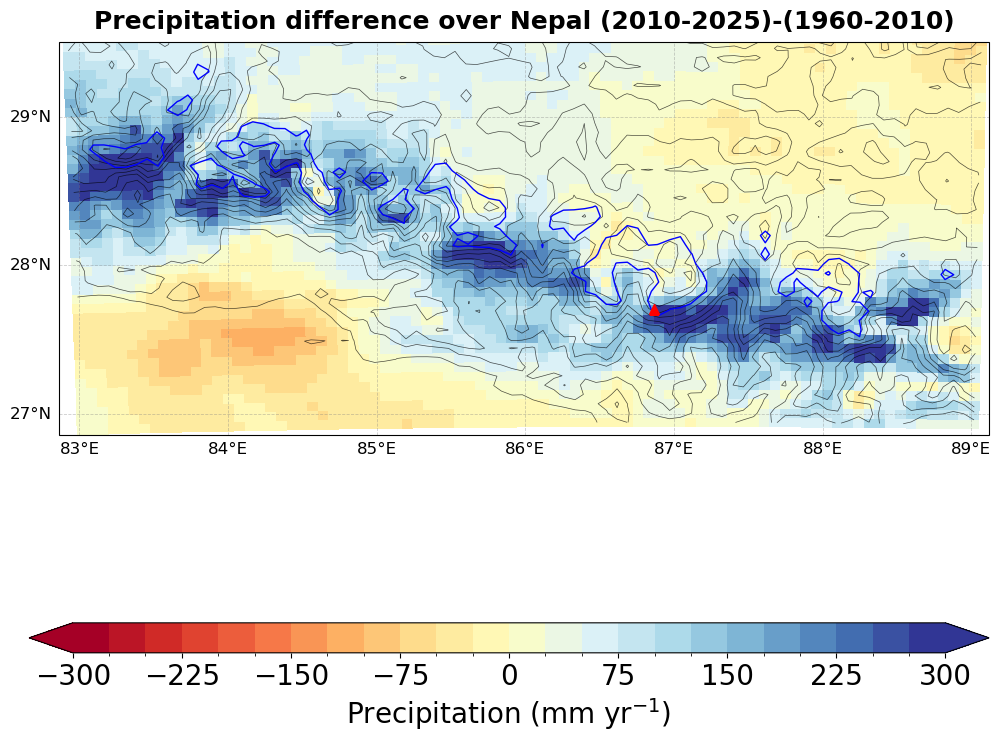

In [13]:
############### TF diff MAP of Nepal (2010-2025)-(1960-2010) #######################

fig, ax = plt.subplots(figsize=(12,12),subplot_kw={'projection': ccrs.PlateCarree()}) # Utilisation de la projection plate carré

data_masked = tf_diff.where(tf_diff != 0) # Permet de mettre en blanc les valeurs strictement égales à 0

############# Color map ###############
vmax = 300
step = 25
levels = np.arange(-vmax, vmax + step, step)
base_cmap = plt.get_cmap("RdYlBu", len(levels)-1)
colors = base_cmap(np.arange(base_cmap.N))

cmap = mcolors.ListedColormap(colors)
#cmap.set_bad(color="white")
norm = mcolors.BoundaryNorm(levels, ncolors=len(colors))


########################################
############### Plot ###################

########### Topography lines #############
SH = ax.contour(ds_lon, ds_lat, ds_SH, levels=np.arange(500, 7001, 500), colors="k", linewidths=0.5, alpha=0.7, transform=ccrs.PlateCarree())

######## Countour glaciers #########
ax.contour(ds_lon, ds_lat, ds_ICE, levels=[ice_level], colors="b", linewidths=1, transform=ccrs.PlateCarree()) # Défini les lignes de contour des glaciers (bleu) où la grille dépasse la valeur de ice_level

######## Mera Peak coord #########
ax.plot(merap_lon, merap_lat, marker='^', markersize=7, markerfacecolor='red', markeredgecolor='red', transform=ccrs.PlateCarree()) # Coord exact du Mera Peak


############# TF moyen par point de grille ##############
im = ax.pcolormesh(ds_lon, ds_lat, data_masked, cmap=cmap, norm=norm, transform=ccrs.PlateCarree(),shading="auto") 


########### Graphic features ############
gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.6,color="gray",alpha=0.4,linestyle="--")
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 12}
gl.ylabel_style = {"size": 12}
gl.xlocator = mticker.MaxNLocator(7)  # max 7 ticks
gl.ylocator = mticker.MaxNLocator(3)

lon_min, lon_max, lat_min, lat_max = ax.get_extent(ccrs.PlateCarree())
ax.set_extent([lon_min, lon_max, lat_min, 29.5],crs=ccrs.PlateCarree())


ax.set_title(f"Precipitation difference over Nepal ({2010}-{fyear})-({iyear}-{2010})",fontsize=18,weight="bold", pad=10)

######################################
######################################


############## Color bar ##################
cbar_ax = fig.add_axes([0.1, 0.15, 0.8, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='both')
cbar.set_label("Precipitation (mm yr$^{-1}$)", fontsize=20)
cbar.ax.tick_params(labelsize=20)

#plt.savefig("Mean_TF_diff_Nepal.png")

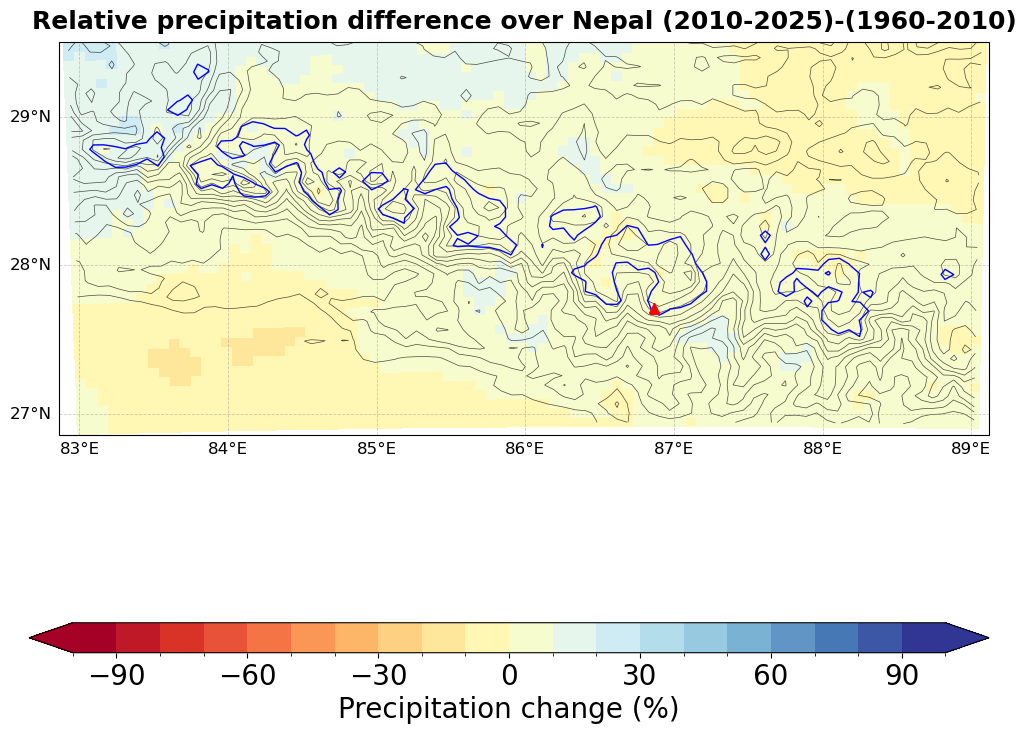

In [14]:
############### Relative TF diff MAP of Nepal (2010-2025)-(1960-2010) #######################

fig, ax = plt.subplots(figsize=(12,12),subplot_kw={'projection': ccrs.PlateCarree()}) # Utilisation de la projection plate carré

############# Différence relative (%) ##############

tf_diff_percent = (tf_diff/tf_1)*100 # (periode_2 - periode_1) / periode_1 *100

tf_diff_percent = tf_diff_percent.where(annual_mean > 0) # Évite les divisions par zéro

data_masked = tf_diff_percent.where(np.isfinite(tf_diff_percent))

############# Color map ###############
vmax = 100
step = 10
levels = np.arange(-vmax, vmax + step, step)
base_cmap = plt.get_cmap("RdYlBu", len(levels)-1)
colors = base_cmap(np.arange(base_cmap.N))

cmap = mcolors.ListedColormap(colors)
#cmap.set_bad(color="white")
norm = mcolors.BoundaryNorm(levels, ncolors=len(colors))


########################################
############### Plot ###################

########### Topography lines #############
SH = ax.contour(ds_lon, ds_lat, ds_SH, levels=np.arange(500, 7001, 500), colors="k", linewidths=0.5, alpha=0.7, transform=ccrs.PlateCarree())

######## Countour glaciers #########
ax.contour(ds_lon, ds_lat, ds_ICE, levels=[ice_level], colors="b", linewidths=1, transform=ccrs.PlateCarree()) # Défini les lignes de contour des glaciers (bleu) où la grille dépasse la valeur de ice_level

######## Mera Peak coord #########
ax.plot(merap_lon, merap_lat, marker='^', markersize=7, markerfacecolor='red', markeredgecolor='red', transform=ccrs.PlateCarree()) # Coord exact du Mera Peak


############# TF moyen par point de grille ##############
im = ax.pcolormesh(ds_lon, ds_lat, data_masked, cmap=cmap, norm=norm, transform=ccrs.PlateCarree(),shading="auto") 


########### Graphic features ############
gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.6,color="gray",alpha=0.4,linestyle="--")
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 12}
gl.ylabel_style = {"size": 12}
gl.xlocator = mticker.MaxNLocator(7)  # max 7 ticks
gl.ylocator = mticker.MaxNLocator(3)

lon_min, lon_max, lat_min, lat_max = ax.get_extent(ccrs.PlateCarree())
ax.set_extent([lon_min, lon_max, lat_min, 29.5],crs=ccrs.PlateCarree())


ax.set_title(f"Relative precipitation difference over Nepal ({2010}-{fyear})-({iyear}-{2010})",fontsize=18,weight="bold", pad=10)

######################################
######################################


############## Color bar ##################
cbar_ax = fig.add_axes([0.1, 0.15, 0.8, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='both')
cbar.set_label("Precipitation change (%)", fontsize=20)
cbar.ax.tick_params(labelsize=20)

plt.savefig("Mean_TF_diff%_Nepal.png")

# Trend of TF over Khumbu and Nepal

In [15]:
def trend_vect(x,y,dim): # Fonction donné par Jérémy pour calcul de trend
    '''
    Compute the spatial trend vectorized, instead of grid by grid.
    ex:
    par=trend_vect(vals.time,vals,'time')

    Source:https://stackoverflow.com/questions/52094320/with-xarray-how-to-parallelize-1d-operations-on-a-multidimensional-dataset
    https://github.com/mickaellalande/MC-Toolkit/blob/master/conda_environment_xarray_xesmf_proplot/xarray/advanced-analysis.ipynb
    
    You can also use a loop on lon/lat but way longer!-> spatial_regression()
    '''
    #print('trend-0','intercept-1','rvalue-2','pvalue-3','stderr-4')
    return xr.apply_ufunc(
        stats.linregress, x, y,
        input_core_dims=[[dim], [dim]],
        output_core_dims=[[], [], [], [], []],
        vectorize=True
        )

In [16]:
ds = TF.sel(time=slice(f"{iyear-1}-12", f"{fyear}-12"))

annual_values = ds.groupby("time.year").sum(dim="time", skipna=True)

annual_values = annual_values.load()

annual_mean = annual_values.mean(dim="year", skipna=True)

slope, intercept, rvalue, pvalue, stderr = trend_vect(annual_values.year, annual_values, dim="year")
annual_trend = slope * 10 

############### Pour l'expression en % par decade ###################
annual_trend_percent = (annual_trend / annual_mean) * 100 # Tendance relative (% par décennie)

annual_trend_percent = annual_trend_percent.where(annual_mean > 0) #  Évite les divisions par zéro

annual_trend_masked = annual_trend_percent.where(np.isfinite(annual_trend_percent))

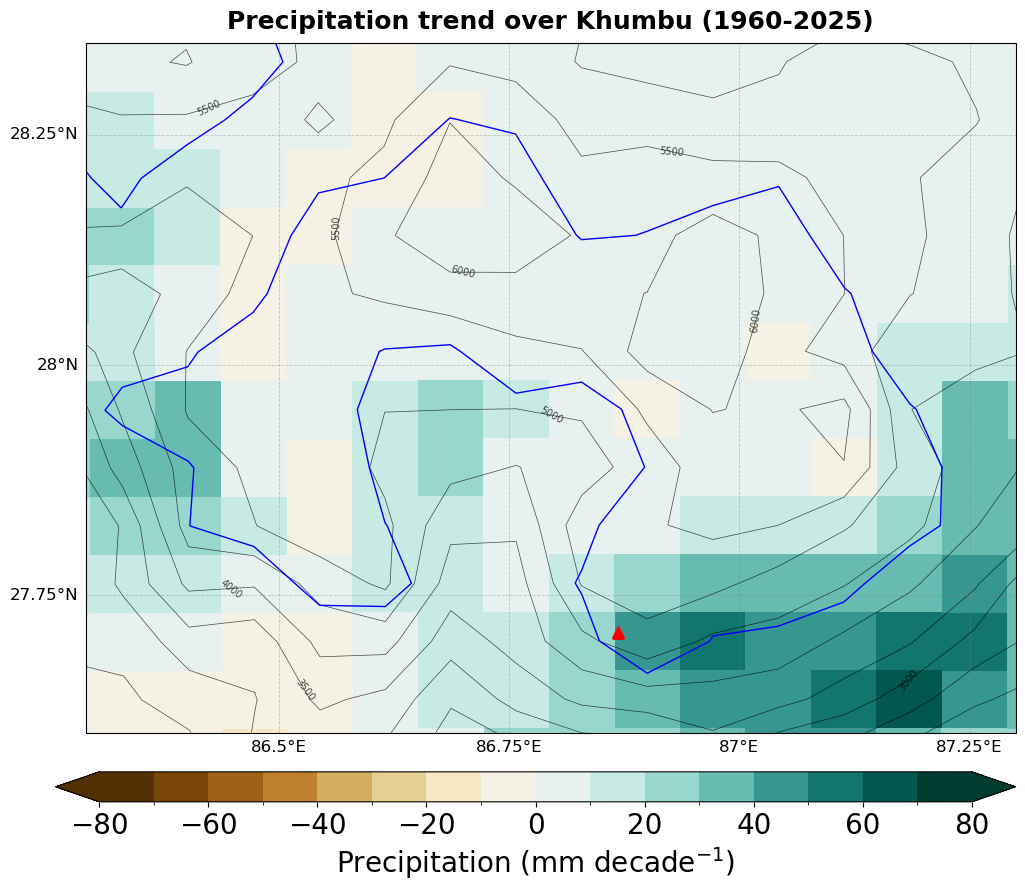

In [17]:
############### TF trend Map ovre Khumbu(1960-2025) #######################

fig, ax = plt.subplots(figsize=(12,12),subplot_kw={'projection': ccrs.PlateCarree()}) # Utilisation de la projection plate carré

############# Color map ###############
vmax = 80
step = 10
levels = np.arange(-vmax, vmax + step, step)
base_cmap = plt.get_cmap("BrBG", len(levels)-1)
colors = base_cmap(np.arange(base_cmap.N))

cmap = mcolors.ListedColormap(colors)
#cmap.set_bad(color="white")
norm = mcolors.BoundaryNorm(levels, ncolors=len(colors))


########################################
############### Plot ###################

########### Topography lines #############
SH = ax.contour(ds_lon, ds_lat, ds_SH, levels=np.arange(500, 7001, 500), colors="k", linewidths=0.5, alpha=0.7, transform=ccrs.PlateCarree())

########### Topography lines values #############
manual_locations = [(86.55, 27.65),(86.4,28.3),(86.45, 27.75),(86.80, 27.95),(87.00, 28.05),(86.55, 28.15),(86.90, 28.20),(87.2,27.65),(86.7,28.1)]
ax.clabel(SH, inline=False, fontsize=7, fmt='%d', manual=manual_locations)

######## Countour glaciers #########
ax.contour(ds_lon, ds_lat, ds_ICE, levels=[ice_level], colors="b", linewidths=1, transform=ccrs.PlateCarree()) # Défini les lignes de contour des glaciers (bleu) où la grille dépasse la valeur de ice_level

######## Mera Peak coord #########
ax.plot(merap_lon, merap_lat, marker='^', markersize=8, markerfacecolor='red', markeredgecolor='red', transform=ccrs.PlateCarree()) # Coord exact du Mera Peak


############# TF moyen par point de grille ##############
im = ax.pcolormesh(ds_lon, ds_lat, annual_trend, cmap=cmap, norm=norm, transform=ccrs.PlateCarree(),shading="auto") 

lon2d = ds_lon.values
lat2d = ds_lat.values

sig = pvalue < 0.05 # On définit les valeurs significatives à partir de la pvalue
step = 1
mask = sig.values

ax.scatter(lon2d[mask], lat2d[mask], color='black', s=8, transform=ccrs.PlateCarree(), zorder=5, alpha=0.5) # Affiche les valeurs significatives des tendances


########### Graphic features ############
gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.6,color="gray",alpha=0.4,linestyle="--")
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 12}
gl.ylabel_style = {"size": 12}
gl.xlocator = mticker.MaxNLocator(5)  # max 5 ticks
gl.ylocator = mticker.MaxNLocator(3)

ax.set_extent([86.29, 87.3, 27.6, 28.35], crs=ccrs.PlateCarree()) # Défini les limites (lon, lat) du domaine observable 

ax.set_title(f"Precipitation trend over Khumbu ({iyear}-{fyear})",fontsize=18,weight="bold", pad=10)

######################################
######################################


############## Color bar ##################
cbar_ax = fig.add_axes([0.1, 0.15, 0.8, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='both')
cbar.set_label("Precipitation (mm decade$^{-1}$)", fontsize=20)
cbar.ax.tick_params(labelsize=20)

#plt.savefig("Trend_TF_Khumbu.png")

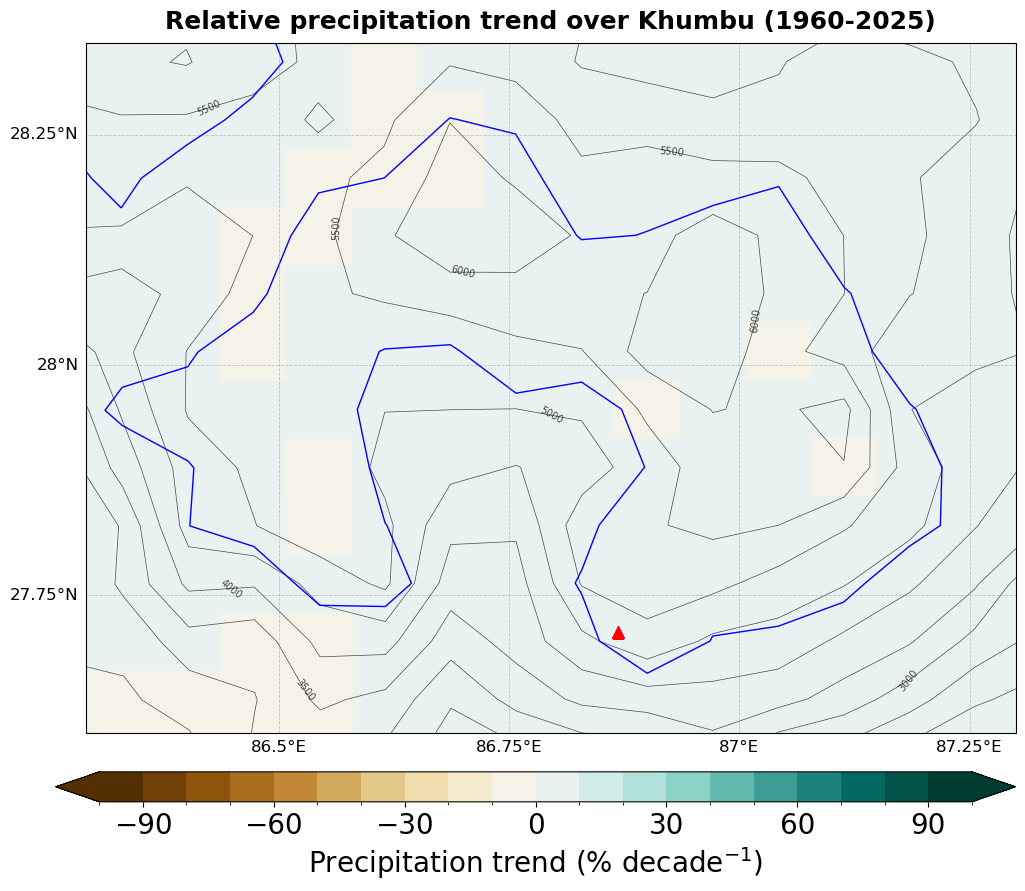

In [18]:
############### Relative TF trend Map ovre Khumbu(1960-2025) #######################

fig, ax = plt.subplots(figsize=(12,12),subplot_kw={'projection': ccrs.PlateCarree()}) # Utilisation de la projection plate carré

############# Color map ###############
vmax = 100
step = 10
levels = np.arange(-vmax, vmax + step, step)
base_cmap = plt.get_cmap("BrBG", len(levels)-1)
colors = base_cmap(np.arange(base_cmap.N))

cmap = mcolors.ListedColormap(colors)
#cmap.set_bad(color="white")
norm = mcolors.BoundaryNorm(levels, ncolors=len(colors))


########################################
############### Plot ###################

########### Topography lines #############
SH = ax.contour(ds_lon, ds_lat, ds_SH, levels=np.arange(500, 7001, 500), colors="k", linewidths=0.5, alpha=0.7, transform=ccrs.PlateCarree())

########### Topography lines values #############
manual_locations = [(86.55, 27.65),(86.4,28.3),(86.45, 27.75),(86.80, 27.95),(87.00, 28.05),(86.55, 28.15),(86.90, 28.20),(87.2,27.65),(86.7,28.1)]
ax.clabel(SH, inline=False, fontsize=7, fmt='%d', manual=manual_locations)

######## Countour glaciers #########
ax.contour(ds_lon, ds_lat, ds_ICE, levels=[ice_level], colors="b", linewidths=1, transform=ccrs.PlateCarree()) # Défini les lignes de contour des glaciers (bleu) où la grille dépasse la valeur de ice_level

######## Mera Peak coord #########
ax.plot(merap_lon, merap_lat, marker='^', markersize=8, markerfacecolor='red', markeredgecolor='red', transform=ccrs.PlateCarree()) # Coord exact du Mera Peak


############# TF moyen par point de grille ##############
im = ax.pcolormesh(ds_lon, ds_lat, annual_trend_masked, cmap=cmap, norm=norm, transform=ccrs.PlateCarree(),shading="auto") 

lon2d = ds_lon.values
lat2d = ds_lat.values

sig = pvalue < 0.05 # On définit les valeurs significatives à partir de la pvalue
step = 1
mask = sig.values

ax.scatter(lon2d[mask], lat2d[mask], color='black', s=8, transform=ccrs.PlateCarree(), zorder=5, alpha=0.5) # Affiche les valeurs significatives des tendances


########### Graphic features ############
gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.6,color="gray",alpha=0.4,linestyle="--")
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 12}
gl.ylabel_style = {"size": 12}
gl.xlocator = mticker.MaxNLocator(5)  # max 5 ticks
gl.ylocator = mticker.MaxNLocator(3)

ax.set_extent([86.29, 87.3, 27.6, 28.35], crs=ccrs.PlateCarree()) # Défini les limites (lon, lat) du domaine observable 

ax.set_title(f"Relative precipitation trend over Khumbu ({iyear}-{fyear})",fontsize=18,weight="bold", pad=10)

######################################
######################################


############## Color bar ##################
cbar_ax = fig.add_axes([0.1, 0.15, 0.8, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='both')
cbar.set_label("Precipitation trend (% decade$^{-1}$)", fontsize=20)
cbar.ax.tick_params(labelsize=20)

plt.savefig("Trend_TF_Khumbu%.png")

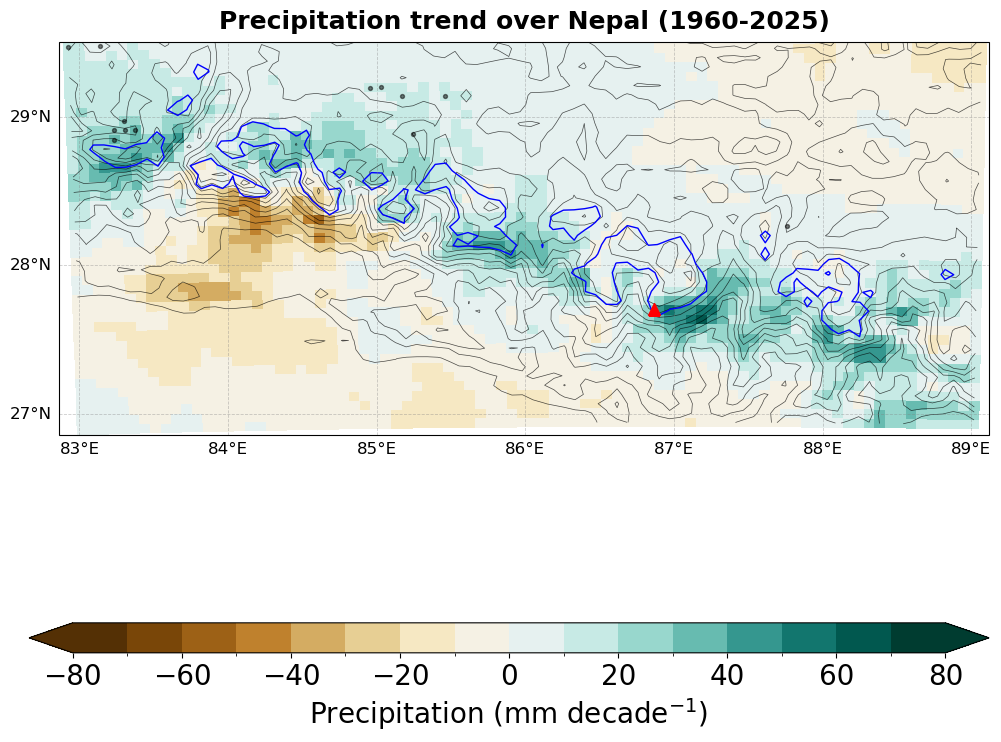

In [19]:
############### TF trend Map Nepal (1960-2025) #######################

fig, ax = plt.subplots(figsize=(12,12),subplot_kw={'projection': ccrs.PlateCarree()}) # Utilisation de la projection plate carré


############# Color map ###############
vmax = 80
step = 10
levels = np.arange(-vmax, vmax + step, step)
base_cmap = plt.get_cmap("BrBG", len(levels)-1)
colors = base_cmap(np.arange(base_cmap.N))

cmap = mcolors.ListedColormap(colors)
#cmap.set_bad(color="white")
norm = mcolors.BoundaryNorm(levels, ncolors=len(colors))


########################################
############### Plot ###################

########### Topography lines #############
SH = ax.contour(ds_lon, ds_lat, ds_SH, levels=np.arange(500, 7001, 500), colors="k", linewidths=0.5, alpha=0.7, transform=ccrs.PlateCarree())

######## Countour glaciers #########
ax.contour(ds_lon, ds_lat, ds_ICE, levels=[ice_level], colors="b", linewidths=1, transform=ccrs.PlateCarree()) # Défini les lignes de contour des glaciers (bleu) où la grille dépasse la valeur de ice_level

######## Mera Peak coord #########
ax.plot(merap_lon, merap_lat, marker='^', markersize=8, markerfacecolor='red', markeredgecolor='red', transform=ccrs.PlateCarree()) # Coord exact du Mera Peak


############# TF moyen par point de grille ##############
im = ax.pcolormesh(ds_lon, ds_lat, annual_trend, cmap=cmap, norm=norm, transform=ccrs.PlateCarree(),shading="auto") 

lon2d = ds_lon.values
lat2d = ds_lat.values

sig = pvalue < 0.05 # On définit les valeurs significatives à partir de la pvalue
step = 1
mask = sig.values

ax.scatter(lon2d[mask], lat2d[mask], color='black', s=8, transform=ccrs.PlateCarree(), zorder=5, alpha=0.5) # Affiche les valeurs significatives des tendances


########### Graphic features ############
gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.6,color="gray",alpha=0.4,linestyle="--")
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 12}
gl.ylabel_style = {"size": 12}
gl.xlocator = mticker.MaxNLocator(7)  # max 7 ticks
gl.ylocator = mticker.MaxNLocator(3)

lon_min, lon_max, lat_min, lat_max = ax.get_extent(ccrs.PlateCarree())
ax.set_extent([lon_min, lon_max, lat_min, 29.5],crs=ccrs.PlateCarree())

ax.set_title(f"Precipitation trend over Nepal ({iyear}-{fyear})",fontsize=18,weight="bold", pad=10)

######################################
######################################


############## Color bar ##################
cbar_ax = fig.add_axes([0.1, 0.15, 0.8, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='both')
cbar.set_label("Precipitation (mm decade$^{-1}$)", fontsize=20)
cbar.ax.tick_params(labelsize=20)

#plt.savefig("Trend_TF_Nepal.png")

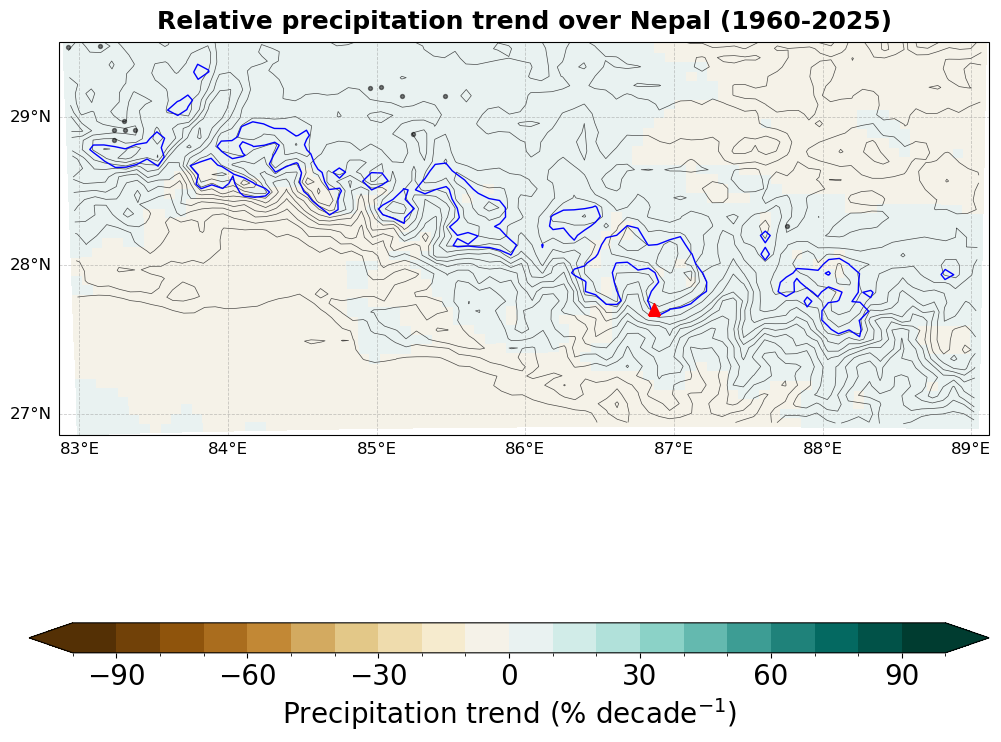

In [20]:
############### Relative TF trend Map Nepal (1960-2025) #######################

fig, ax = plt.subplots(figsize=(12,12),subplot_kw={'projection': ccrs.PlateCarree()}) # Utilisation de la projection plate carré


############# Color map ###############
vmax = 100
step = 10
levels = np.arange(-vmax, vmax + step, step)
base_cmap = plt.get_cmap("BrBG", len(levels)-1)
colors = base_cmap(np.arange(base_cmap.N))

cmap = mcolors.ListedColormap(colors)
#cmap.set_bad(color="white")
norm = mcolors.BoundaryNorm(levels, ncolors=len(colors))


########################################
############### Plot ###################

########### Topography lines #############
SH = ax.contour(ds_lon, ds_lat, ds_SH, levels=np.arange(500, 7001, 500), colors="k", linewidths=0.5, alpha=0.7, transform=ccrs.PlateCarree())

######## Countour glaciers #########
ax.contour(ds_lon, ds_lat, ds_ICE, levels=[ice_level], colors="b", linewidths=1, transform=ccrs.PlateCarree()) # Défini les lignes de contour des glaciers (bleu) où la grille dépasse la valeur de ice_level

######## Mera Peak coord #########
ax.plot(merap_lon, merap_lat, marker='^', markersize=8, markerfacecolor='red', markeredgecolor='red', transform=ccrs.PlateCarree()) # Coord exact du Mera Peak


############# TF moyen par point de grille ##############
im = ax.pcolormesh(ds_lon, ds_lat, annual_trend_masked, cmap=cmap, norm=norm, transform=ccrs.PlateCarree(),shading="auto") 

lon2d = ds_lon.values
lat2d = ds_lat.values

sig = pvalue < 0.05 # On définit les valeurs significatives à partir de la pvalue
step = 1
mask = sig.values

ax.scatter(lon2d[mask], lat2d[mask], color='black', s=8, transform=ccrs.PlateCarree(), zorder=5, alpha=0.5) # Affiche les valeurs significatives des tendances


########### Graphic features ############
gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.6,color="gray",alpha=0.4,linestyle="--")
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 12}
gl.ylabel_style = {"size": 12}
gl.xlocator = mticker.MaxNLocator(7)  # max 7 ticks
gl.ylocator = mticker.MaxNLocator(3)

lon_min, lon_max, lat_min, lat_max = ax.get_extent(ccrs.PlateCarree())
ax.set_extent([lon_min, lon_max, lat_min, 29.5],crs=ccrs.PlateCarree())

ax.set_title(f"Relative precipitation trend over Nepal ({iyear}-{fyear})",fontsize=18,weight="bold", pad=10)

######################################
######################################


############## Color bar ##################
cbar_ax = fig.add_axes([0.1, 0.15, 0.8, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='both')
cbar.set_label("Precipitation trend (% decade$^{-1}$)", fontsize=20)
cbar.ax.tick_params(labelsize=20)

plt.savefig("Trend_TF_Nepal%.png")

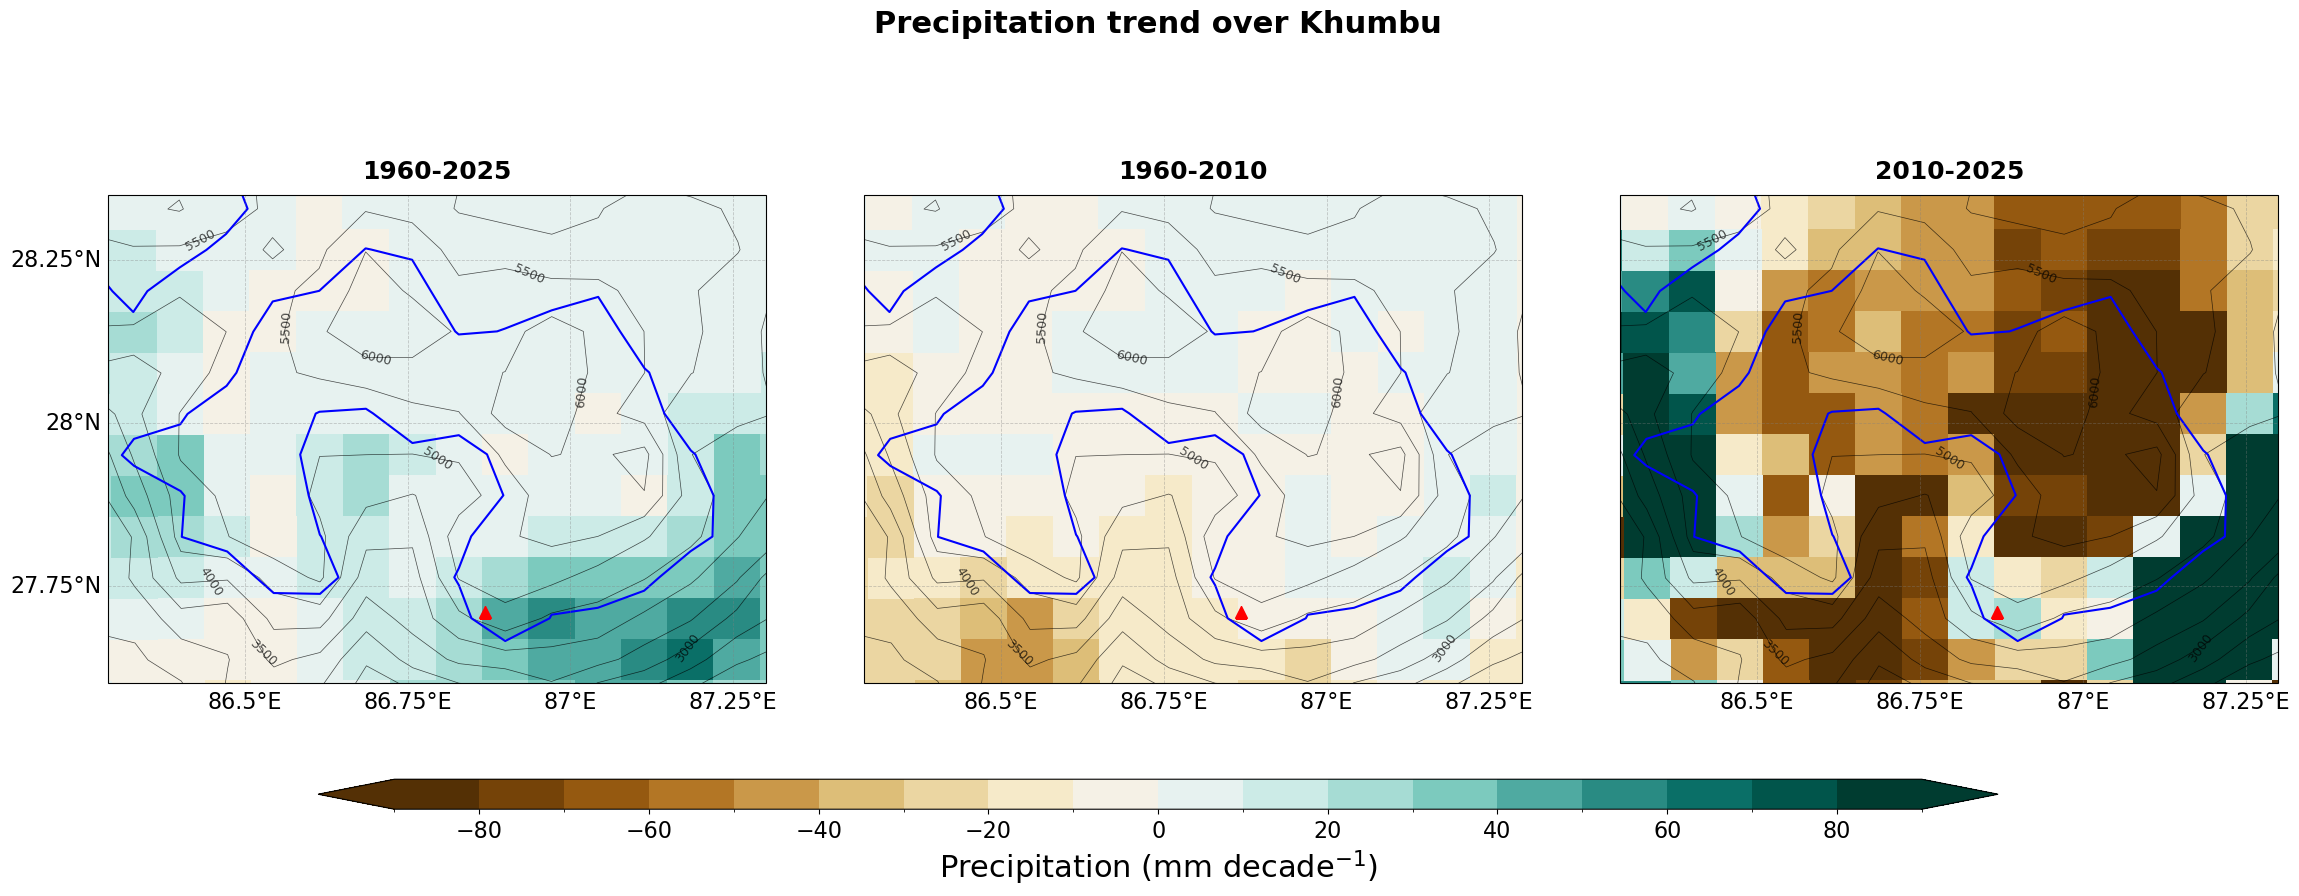

In [21]:
############### Subplot TF trend Map Khumbu (1960-2025) #######################

fig, axes = plt.subplots(1, 3, figsize=(28, 10), subplot_kw={'projection': ccrs.PlateCarree()})

########## Périodes étudiées ##########
periods = [(1960, 2025), (1960, 2010), (2010, 2025)]

########## Color map ###############
vmax = 90
step = 10
levels = np.arange(-vmax, vmax + step, step)
base_cmap = plt.get_cmap("BrBG", len(levels)-1)
colors = base_cmap(np.arange(base_cmap.N))

cmap = mcolors.ListedColormap(colors)
#cmap.set_bad(color="white")
norm = mcolors.BoundaryNorm(levels, ncolors=len(colors))


#############################################################
############### Boucles pour les périodes ###################
for ax, (start, end) in zip(axes, periods):

    ds = TF.sel(time=slice(f"{start}-01", f"{end}-12")) # Selection de période

    annual_values = ds.groupby("time.year").sum(dim='time', skipna=True)
    annual_values = annual_values.load()
    years = annual_values["year"].values
    slope, intercept, rvalue, pvalue, stderr = trend_vect(years, annual_values, dim="year")
    annual_trend = slope * 10 

    ############### Plot ###################
    ########### Topography lines #############
    SH = ax.contour(ds_lon, ds_lat, ds_SH, levels=np.arange(500, 7001, 500), colors="k", linewidths=0.5, alpha=0.7, transform=ccrs.PlateCarree())

    ########### Topography lines values #############
    manual_locations = [(86.55, 27.65),(86.4,28.3),(86.45, 27.75),(86.80, 27.95),(87.00, 28.05),(86.55, 28.15),(86.90, 28.20),(87.2,27.65),(86.7,28.1)]
    ax.clabel(SH, inline=False, fontsize=9, fmt='%d', manual=manual_locations)

    ######## Countour glaciers #########
    ax.contour(ds_lon, ds_lat, ds_ICE, levels=[ice_level], colors="b", linewidths=1.5, transform=ccrs.PlateCarree()) # Défini les lignes de contour des glaciers (bleu) où la grille dépasse la valeur de ice_level

    ######## Mera Peak coord #########
    ax.plot(merap_lon, merap_lat, marker='^', markersize=8, markerfacecolor='red', markeredgecolor='red', transform=ccrs.PlateCarree()) # Coord exact du Mera Peak

    ############# TF moyen par point de grille ##############
    im = ax.pcolormesh(ds_lon, ds_lat, annual_trend, cmap=cmap, norm=norm, transform=ccrs.PlateCarree(),shading="auto") 

    lon2d = ds_lon.values
    lat2d = ds_lat.values

    sig = pvalue < 0.05 # On définit les valeurs significatives à partir de la pvalue
    step = 1
    mask = sig.values

    ax.scatter(lon2d[mask], lat2d[mask], color='black', s=8, transform=ccrs.PlateCarree(), zorder=5, alpha=0.6) # Affiche les valeurs significatives des tendances


    
    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.6,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False

    if ax != axes[0]: # labels seulement sur le subplot gauche
        gl.left_labels = False
        
    gl.xlabel_style = {"size": 16}
    gl.ylabel_style = {"size": 16}
    gl.xlocator = mticker.MaxNLocator(5)  # max 5 ticks
    gl.ylocator = mticker.MaxNLocator(3)

    ax.set_extent([86.29, 87.3, 27.6, 28.35], crs=ccrs.PlateCarree()) # Défini les limites (lon, lat) du domaine observable 
    ax.set_title(f"{start}-{end}",fontsize=18,weight="bold", pad=12)

#######################################################################
#######################################################################    

fig.suptitle("Precipitation trend over Khumbu", fontsize=22, weight="bold", y=0.93) 

cbar_ax = fig.add_axes([0.2, 0.13, 0.6, 0.03])

cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='both')

cbar.set_label("Precipitation (mm decade$^{-1}$)", fontsize=22)

cbar.ax.tick_params(labelsize=16)

plt.subplots_adjust(wspace=0.15,top=0.88,bottom=0.12)

#plt.savefig("Trend_precip_sub.png", dpi=400, bbox_inches="tight")



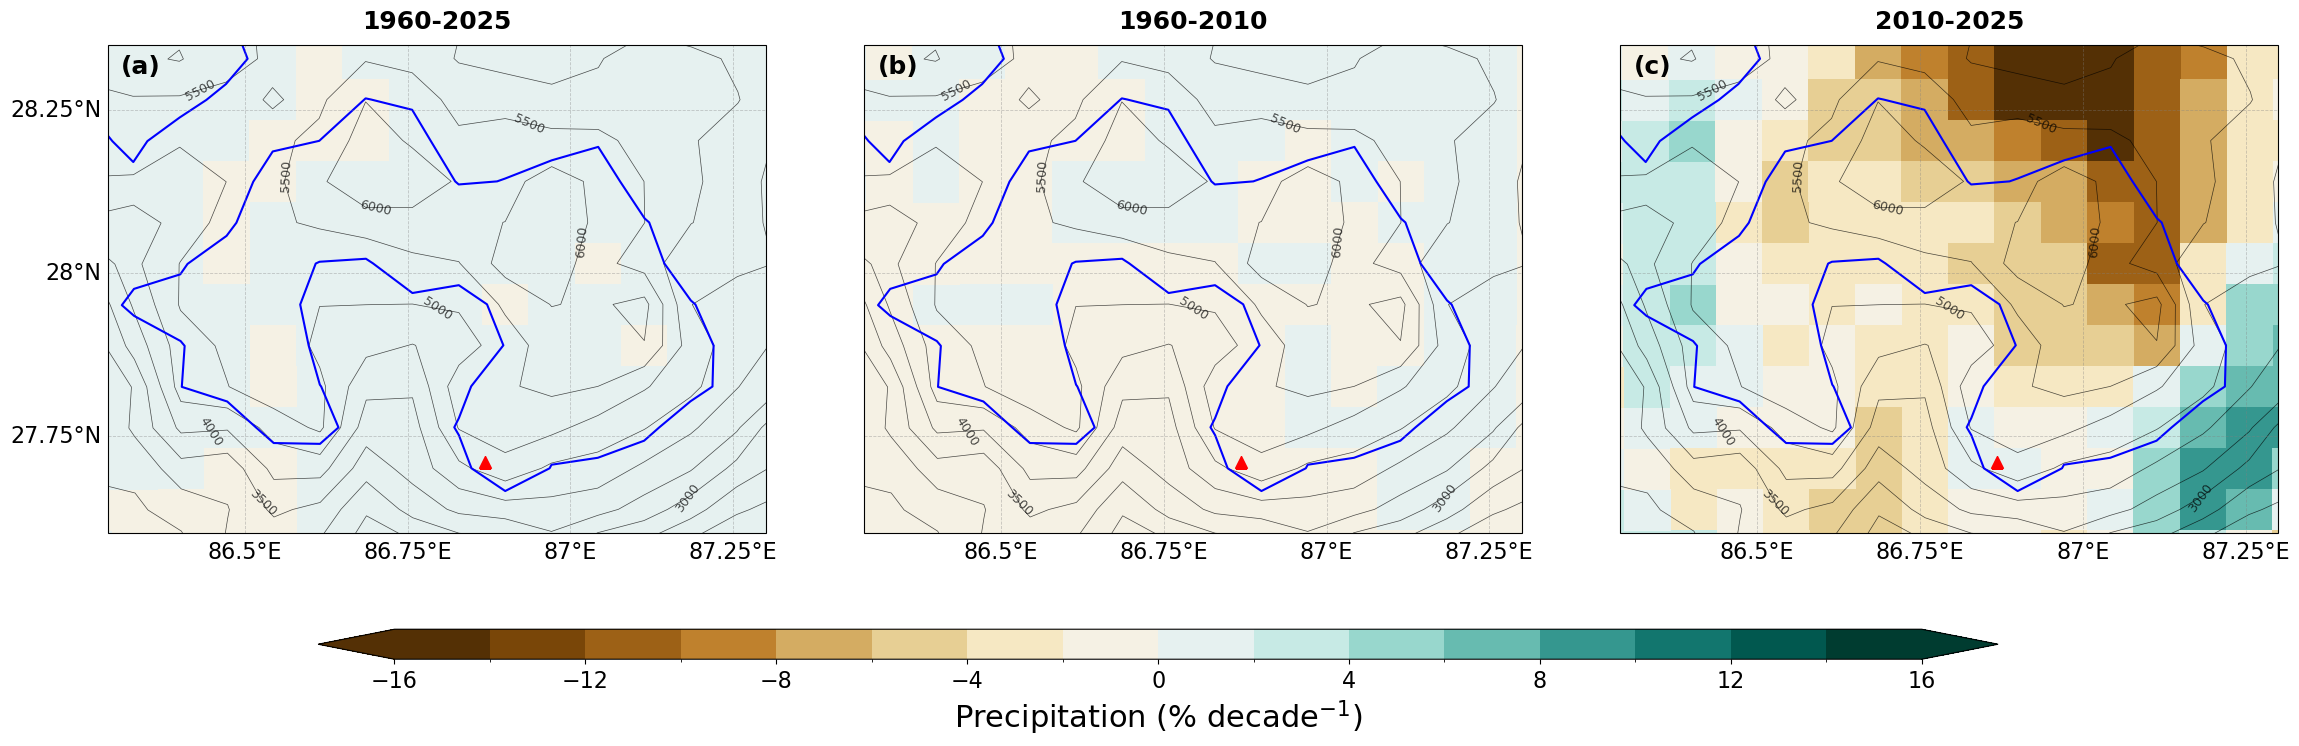

In [22]:
############### Subplot TF trend Map Khumbu (1960-2025) #######################

fig, axes = plt.subplots(1, 3, figsize=(28, 10), subplot_kw={'projection': ccrs.PlateCarree()})

########## Périodes étudiées ##########
periods = [(1960, 2025), (1960, 2010), (2010, 2025)]

########## Color map ###############
vmax = 16
step = 2
levels = np.arange(-vmax, vmax + step, step)
base_cmap = plt.get_cmap("BrBG", len(levels)-1)
colors = base_cmap(np.arange(base_cmap.N))

cmap = mcolors.ListedColormap(colors)
#cmap.set_bad(color="white")
norm = mcolors.BoundaryNorm(levels, ncolors=len(colors))

panel_labels = ["(a)", "(b)", "(c)"]

#############################################################
############### Boucles pour les périodes ###################
for ax, (start, end), label in zip(axes, periods, panel_labels):

    ds = TF.sel(time=slice(f"{start}-01", f"{end}-12")) # Selection de période

    annual_values = ds.groupby("time.year").sum(dim='time', skipna=True)
    annual_values = annual_values.load()
    years = annual_values["year"].values
    slope, intercept, rvalue, pvalue, stderr = trend_vect(years, annual_values, dim="year")
    annual_trend = slope * 10 

    ############### Pour l'expression en % par decade ###################
    annual_trend_percent = (annual_trend / annual_mean) * 100 # Tendance relative (% par décennie)

    annual_trend_percent = annual_trend_percent.where(annual_mean > 0) #  Évite les divisions par zéro

    annual_trend_masked = annual_trend_percent.where(np.isfinite(annual_trend_percent))


    ############### Plot ###################
    ########### Topography lines #############
    SH = ax.contour(ds_lon, ds_lat, ds_SH, levels=np.arange(500, 7001, 500), colors="k", linewidths=0.5, alpha=0.7, transform=ccrs.PlateCarree())

    ########### Topography lines values #############
    manual_locations = [(86.55, 27.65),(86.4,28.3),(86.45, 27.75),(86.80, 27.95),(87.00, 28.05),(86.55, 28.15),(86.90, 28.20),(87.2,27.65),(86.7,28.1)]
    ax.clabel(SH, inline=False, fontsize=9, fmt='%d', manual=manual_locations)

    ######## Countour glaciers #########
    ax.contour(ds_lon, ds_lat, ds_ICE, levels=[ice_level], colors="b", linewidths=1.5, transform=ccrs.PlateCarree()) # Défini les lignes de contour des glaciers (bleu) où la grille dépasse la valeur de ice_level

    ######## Mera Peak coord #########
    ax.plot(merap_lon, merap_lat, marker='^', markersize=8, markerfacecolor='red', markeredgecolor='red', transform=ccrs.PlateCarree()) # Coord exact du Mera Peak

    ############# TF moyen par point de grille ##############
    im = ax.pcolormesh(ds_lon, ds_lat, annual_trend_masked, cmap=cmap, norm=norm, transform=ccrs.PlateCarree(),shading="auto") 

    lon2d = ds_lon.values
    lat2d = ds_lat.values

    sig = pvalue < 0.05 # On définit les valeurs significatives à partir de la pvalue
    step = 1
    mask = sig.values

    ax.scatter(lon2d[mask], lat2d[mask], color='black', s=8, transform=ccrs.PlateCarree(), zorder=5, alpha=0.6) # Affiche les valeurs significatives des tendances


    
    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.6,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False

    if ax != axes[0]: # labels seulement sur le subplot gauche
        gl.left_labels = False
        
    gl.xlabel_style = {"size": 16}
    gl.ylabel_style = {"size": 16}
    gl.xlocator = mticker.MaxNLocator(5)  # max 5 ticks
    gl.ylocator = mticker.MaxNLocator(3)

    ax.set_extent([86.29, 87.3, 27.6, 28.35], crs=ccrs.PlateCarree()) # Défini les limites (lon, lat) du domaine observable 
    ax.set_title(f"{start}-{end}",fontsize=18,weight="bold", pad=12)

    ax.text(0.02, 0.98, label, transform=ax.transAxes, fontsize=18, fontweight='bold', va='top', ha='left')

#######################################################################
#######################################################################    

#fig.suptitle("Precipitation trend over Khumbu", fontsize=22, weight="bold", y=0.93) 

cbar_ax = fig.add_axes([0.2, 0.13, 0.6, 0.03])

cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='both')

cbar.set_label("Precipitation (% decade$^{-1}$)", fontsize=22)

cbar.ax.tick_params(labelsize=16)

plt.subplots_adjust(wspace=0.15,top=0.88,bottom=0.12)

plt.savefig("Trend_TF_Khumbu_subperiod%.png", dpi=400, bbox_inches="tight")


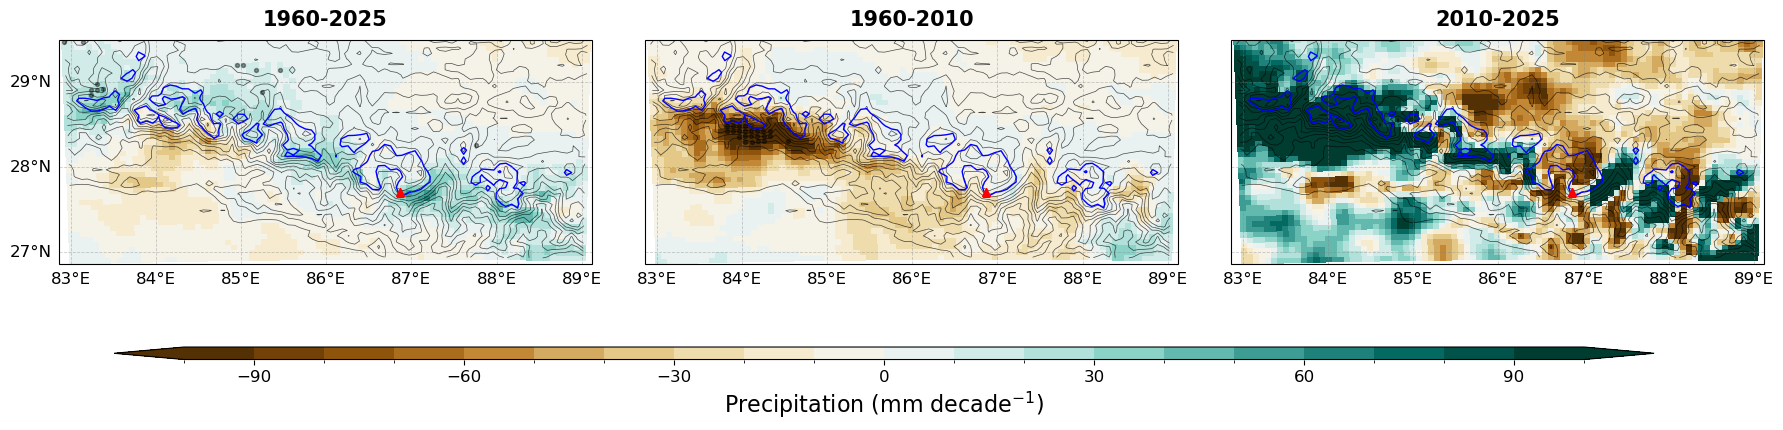

In [23]:
############### Subplot TF trend Map Nepal (1960-2025) #######################

fig, axes = plt.subplots(1, 3, figsize=(22, 5), subplot_kw={'projection': ccrs.PlateCarree()})

########## Périodes étudiées ##########
periods = [(1960, 2025), (1960, 2010), (2010, 2025)]

########## Color map ###############
vmax = 100
step = 10
levels = np.arange(-vmax, vmax + step, step)
base_cmap = plt.get_cmap("BrBG", len(levels)-1)
colors = base_cmap(np.arange(base_cmap.N))

cmap = mcolors.ListedColormap(colors)
#cmap.set_bad(color="white")
norm = mcolors.BoundaryNorm(levels, ncolors=len(colors))


#############################################################
############### Boucles pour les périodes ###################
for ax, (start, end) in zip(axes, periods):

    ds = TF.sel(time=slice(f"{start}-01", f"{end}-12")) # Selection de période

    annual_values = ds.groupby("time.year").sum(dim='time', skipna=True)
    annual_values = annual_values.load()
    years = annual_values["year"].values
    slope, intercept, rvalue, pvalue, stderr = trend_vect(years, annual_values, dim="year")
    annual_trend = slope * 10 
    annual_trend_masked = annual_trend.where(annual_trend != 0) # Permet de mettre en blanc les valeurs strictement égales à 0


    ############### Plot ###################
    ########### Topography lines #############
    SH = ax.contour(ds_lon, ds_lat, ds_SH, levels=np.arange(500, 7001, 500), colors="k", linewidths=0.5, alpha=0.7, transform=ccrs.PlateCarree())

    ######## Countour glaciers #########
    ax.contour(ds_lon, ds_lat, ds_ICE, levels=[ice_level], colors="b", linewidths=1, transform=ccrs.PlateCarree()) # Défini les lignes de contour des glaciers (bleu) où la grille dépasse la valeur de ice_level

    ######## Mera Peak coord #########
    ax.plot(merap_lon, merap_lat, marker='^', markersize=6, markerfacecolor='red', markeredgecolor='red', transform=ccrs.PlateCarree()) # Coord exact du Mera Peak

    ############# TF moyen par point de grille ##############
    im = ax.pcolormesh(ds_lon, ds_lat, annual_trend, cmap=cmap, norm=norm, transform=ccrs.PlateCarree(),shading="auto") 

    lon2d = ds_lon.values
    lat2d = ds_lat.values

    sig = pvalue < 0.05 # On définit les valeurs significatives à partir de la pvalue
    step = 1
    mask = sig.values

    ax.scatter(lon2d[mask], lat2d[mask], color='black', s=8, transform=ccrs.PlateCarree(), zorder=5, alpha=0.4) # Affiche les valeurs significatives des tendances


    
    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.6,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False

    if ax != axes[0]: # labels seulement sur le subplot gauche
        gl.left_labels = False
        
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}
    gl.xlocator = mticker.MaxNLocator(7)  # max 7 ticks
    gl.ylocator = mticker.MaxNLocator(3)

    lon_min, lon_max, lat_min, lat_max = ax.get_extent(ccrs.PlateCarree())
    ax.set_extent([lon_min, lon_max, lat_min, 29.5],crs=ccrs.PlateCarree())

    ax.set_title(f"{start}-{end}",fontsize=15,weight="bold", pad=10)

#######################################################################
#######################################################################    


cbar_ax = fig.add_axes([0.15, 0.08, 0.7, 0.025])

cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='both')

cbar.set_label("Precipitation (mm decade$^{-1}$)", fontsize=16)

cbar.ax.tick_params(labelsize=12)

plt.subplots_adjust(wspace=0.1) # Espacement subplots

#plt.savefig("Trend_precip_sub.png")